# Hybrid Ensemble Notebook: PatchTST + Tree Models + Meta-MLP

## Study Objective
This notebook evaluates a historical-window wildfire classification pipeline built from four causal windows of meteorological, fuel, topographic, and VIIRS-derived predictors. The workflow contains three modeling stages: (1) a PatchTST+DLA neural classifier trained on the normalized sequence tensor, (2) tree-based baselines trained on flattened statistical summaries of the same inputs, and (3) a stacking meta-classifier trained on validation probabilities from the base models.

## Analysis Plan
1. Merge base and VIIRS feature tables and retain complete four-window samples only.
2. Train the PatchTST+DLA neural branch and obtain validation/test probabilities.
3. Estimate PatchTST feature attribution with SHAP on a held-out validation subset.
4. Train tree-based baselines from flat statistical features.
5. Combine base-model probabilities in a meta-MLP and compare final performance.


In [1]:
# Optional installs on Kaggle
!pip -q install huggingface_hub scikit-learn xgboost catboost lightgbm shap


In [2]:
from pathlib import Path
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from huggingface_hub import hf_hub_download

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# Optional tree imports (will be guarded)
TREE_IMPORTS = {'xgboost': False, 'catboost': False, 'lightgbm': False}
try:
    import xgboost as xgb
    TREE_IMPORTS['xgboost'] = True
except Exception:
    pass

try:
    import catboost as cb
    TREE_IMPORTS['catboost'] = True
except Exception:
    pass

try:
    import lightgbm as lgb
    TREE_IMPORTS['lightgbm'] = True
except Exception:
    pass

print('Tree imports:', TREE_IMPORTS)


Tree imports: {'xgboost': True, 'catboost': True, 'lightgbm': True}


## Data Preparation

The feature tables are first aligned by `target_date`, `row`, `col`, and `window_id`. Only cells with complete four-window histories are retained. The neural branch uses train-only feature normalization, while the tree branch later uses a separate flat statistical representation.


In [3]:
# -------------------------
# Load MODEL/src package
# -------------------------
SRC_CANDIDATES = [
    Path('/kaggle/input/models/nagrajgaonkar/nagrajmg/pytorch/cv5600/1')
]

MODEL_SRC = None
for cand in SRC_CANDIDATES:
    if cand.exists():
        MODEL_SRC = cand
        break
if MODEL_SRC is None:
    raise FileNotFoundError(f'Could not find MODEL/src from: {SRC_CANDIDATES}')

if str(MODEL_SRC) not in sys.path:
    sys.path.insert(0, str(MODEL_SRC))

from src.configs import DataConfig, ModelConfig, TrainConfig
from src.data_io import load_split_xy_csv, FeatureNormalizer, make_torch_datasets
from src.model_patchtst_dla import PatchTSTDLAClassifier
from src.trainer import make_dataloaders, fit_model, evaluate_with_threshold_search
from src.utils import set_seed, device_summary

print('Using MODEL_SRC:', MODEL_SRC)

Using MODEL_SRC: /kaggle/input/models/nagrajgaonkar/nagrajmg/pytorch/cv5600/1


In [4]:
# -------------------------
# Config
# -------------------------
SEED = 68
set_seed(SEED, deterministic=True)
np.random.seed(SEED)

# HF dataset repositories
HF_X_REPO = 'NagrajMG/WildFire-X'
HF_Y_REPO = 'NagrajMG/WildFire-Y'
HF_TOKEN = os.getenv('HF_TOKEN', None)

# HF file templates
HF_X_BASE_FILE_TEMPLATE = 'FEATURES_{split}.csv'
HF_X_VIIRS_FILE_TEMPLATE = 'FEATURES_{split}_viirs.csv'
EXPECTED_VIIRS_FEATURES = 18
HF_Y_FILE_TEMPLATE = 'LABELS_{split}.csv'

# Enable extra VIIRS features
USE_VIIRS_FEATURES = True
STRICT_VIIRS_KEY_MATCH = True  # if True, fail when any base key has no VIIRS match

# Read Kaggle secret if available
try:
    from kaggle_secrets import UserSecretsClient
    HF_TOKEN = UserSecretsClient().get_secret('HUGGINGFACE_TOKEN')
except Exception:
    pass

WORK_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('/tmp')
ARTIFACT_DIR = WORK_DIR / 'ensemble_patchtst_tree'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

USE_MULTI_GPU = True
REQUIRE_TWO_GPUS = True

print('Artifacts:', ARTIFACT_DIR)
print('GPU summary:', device_summary())
print('USE_VIIRS_FEATURES:', USE_VIIRS_FEATURES)

Artifacts: /kaggle/working/ensemble_patchtst_tree
GPU summary: {'cuda_available': True, 'n_gpu': 2, 'gpu_names': ['Tesla T4', 'Tesla T4']}
USE_VIIRS_FEATURES: True


In [5]:
# -------------------------
# Download split CSVs from HF (base + optional VIIRS + labels)
# -------------------------
SPLITS = ['train', 'val', 'test']
paths = {}
for split in SPLITS:
    # Base features
    paths[f'x_base_{split}'] = hf_hub_download(
        repo_id=HF_X_REPO,
        filename=HF_X_BASE_FILE_TEMPLATE.format(split=split),
        repo_type='dataset',
        token=HF_TOKEN,
        cache_dir=WORK_DIR / 'hf_cache',
    )

    # Optional VIIRS features (18 extra columns)
    if USE_VIIRS_FEATURES:
        paths[f'x_viirs_{split}'] = hf_hub_download(
            repo_id=HF_X_REPO,
            filename=HF_X_VIIRS_FILE_TEMPLATE.format(split=split),
            repo_type='dataset',
            token=HF_TOKEN,
            cache_dir=WORK_DIR / 'hf_cache',
        )

    # Labels
    paths[f'y_{split}'] = hf_hub_download(
        repo_id=HF_Y_REPO,
        filename=HF_Y_FILE_TEMPLATE.format(split=split),
        repo_type='dataset',
        token=HF_TOKEN,
        cache_dir=WORK_DIR / 'hf_cache',
    )

print(json.dumps(paths, indent=2))

{
  "x_base_train": "/kaggle/working/hf_cache/datasets--NagrajMG--WildFire-X/snapshots/6c3fd5e077deaa7afeb4b8ae10860505a3440633/FEATURES_train.csv",
  "x_viirs_train": "/kaggle/working/hf_cache/datasets--NagrajMG--WildFire-X/snapshots/6c3fd5e077deaa7afeb4b8ae10860505a3440633/FEATURES_train_viirs.csv",
  "y_train": "/kaggle/working/hf_cache/datasets--NagrajMG--WildFire-Y/snapshots/5c10f82574a79f7dc8939387f7e39e1c275ba0dc/LABELS_train.csv",
  "x_base_val": "/kaggle/working/hf_cache/datasets--NagrajMG--WildFire-X/snapshots/6c3fd5e077deaa7afeb4b8ae10860505a3440633/FEATURES_val.csv",
  "x_viirs_val": "/kaggle/working/hf_cache/datasets--NagrajMG--WildFire-X/snapshots/6c3fd5e077deaa7afeb4b8ae10860505a3440633/FEATURES_val_viirs.csv",
  "y_val": "/kaggle/working/hf_cache/datasets--NagrajMG--WildFire-Y/snapshots/5c10f82574a79f7dc8939387f7e39e1c275ba0dc/LABELS_val.csv",
  "x_base_test": "/kaggle/working/hf_cache/datasets--NagrajMG--WildFire-X/snapshots/6c3fd5e077deaa7afeb4b8ae10860505a3440633/FEA

In [6]:
# -------------------------
# Best params for PatchTST + DLA (from Optuna)
# -------------------------
best_params = {
  "dmodel_heads": "160x10",
  "patch_len": 4,
  "patch_stride": 2,
  "n_layers": 8,
  "ff_mult": 4,
  "dropout": 0.2749472089185977,
  "attn_dropout": 0.2991027162890036,
  "mla_hidden": 192,
  "head_hidden": 128,
  "use_temporal_dlad": True,
  "temporal_dla_base_channels": 32,
  "use_temporal_attention_pool": True,
  "use_window_embedding": False,
  "use_summary_branches": False,
  "use_gated_fusion": True,
  "fusion_hidden": 128,
  "use_feature_mixer": True,
  "feature_mixer_hidden_mult": 1,
  "feature_mixer_dropout": 0.2,
  "use_tabular_shortcut": True,
  "tabular_hidden": 256,
  "batch_size": 256,
  "lr": 0.002444154311705661,
  "weight_decay": 0.00007584795949531318,
  "grad_clip_norm": 3.0,
  "patience": 10,
  "loss_name": "bce",
  "pos_weight": 1.0,
  "focal_gamma": 2.5,
  "scheduler_name": "none",
  "min_lr": 0.00001
}

def parse_d_model_n_heads(params):
    if "dmodel_heads" in params:
        d_model, n_heads = [int(v) for v in str(params["dmodel_heads"]).split("x")]
    elif "d_model_n_heads" in params:
        d_model, n_heads = [int(v) for v in str(params["d_model_n_heads"]).split("|")]
    else:
        d_model = int(params["d_model"])
        n_heads = int(params["n_heads"])

    if d_model % n_heads != 0:
        raise ValueError(f"Invalid params: d_model={d_model}, n_heads={n_heads}")

    return d_model, n_heads

BEST_D_MODEL, BEST_N_HEADS = parse_d_model_n_heads(best_params)
BEST_BATCH_SIZE = int(best_params.get("batch_size", 256))

print("Loaded best_params for PatchTST branch.")
print("d_model, n_heads:", BEST_D_MODEL, BEST_N_HEADS)
print("batch_size:", BEST_BATCH_SIZE)

Loaded best_params for PatchTST branch.
d_model, n_heads: 160 10
batch_size: 256


In [7]:
# -------------------------
# Merge base + VIIRS feature CSVs per split, then load arrays
# -------------------------
data_cfg = DataConfig(expected_windows=4, batch_size=BEST_BATCH_SIZE, num_workers=4, pin_memory=True, drop_last_train=False)

KEY_COLS = ['target_date', 'row', 'col', 'window_id']


def _merge_feature_csvs(base_csv, viirs_csv, out_csv, split_name, strict_match=True):
    base_df = pd.read_csv(base_csv)
    viirs_df = pd.read_csv(viirs_csv)

    for c in KEY_COLS:
        if c not in base_df.columns:
            raise ValueError(f"{base_csv} missing key column: {c}")
        if c not in viirs_df.columns:
            raise ValueError(f"{viirs_csv} missing key column: {c}")

    base_df = base_df.drop_duplicates(KEY_COLS, keep='first').copy()
    viirs_df = viirs_df.drop_duplicates(KEY_COLS, keep='first').copy()

    viirs_feature_cols = [c for c in viirs_df.columns if c not in KEY_COLS and c != 'split']
    if not viirs_feature_cols:
        raise ValueError(f"No VIIRS feature columns found in {viirs_csv}")

    base_feature_cols = [c for c in base_df.columns if c not in KEY_COLS and c != 'split']
    collisions = sorted(set(base_feature_cols).intersection(viirs_feature_cols))
    if collisions:
        rename_map = {c: f'viirs_{c}' for c in collisions}
        viirs_df = viirs_df.rename(columns=rename_map)
        viirs_feature_cols = [rename_map.get(c, c) for c in viirs_feature_cols]

    viirs_use = viirs_df[KEY_COLS + viirs_feature_cols]
    merged = base_df.merge(viirs_use, on=KEY_COLS, how='left', validate='one_to_one')

    # Key match diagnostics
    all_viirs_missing = merged[viirs_feature_cols].isna().all(axis=1)
    n_missing_keys = int(all_viirs_missing.sum())
    if strict_match and n_missing_keys > 0:
        raise ValueError(
            f"split={split_name}: {n_missing_keys} base keys have no VIIRS feature match. "
            f"Disable STRICT_VIIRS_KEY_MATCH to allow this."
        )

    out_csv = Path(out_csv)
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    merged.to_csv(out_csv, index=False)

    return {
        'rows_base': int(len(base_df)),
        'rows_viirs': int(len(viirs_df)),
        'rows_merged': int(len(merged)),
        'n_viirs_features_added': int(len(viirs_feature_cols)),
        'n_missing_viirs_keys': int(n_missing_keys),
        'viirs_feature_cols': viirs_feature_cols,
    }


merge_stats = {}
merged_dir = ARTIFACT_DIR / 'merged_features'
merged_dir.mkdir(parents=True, exist_ok=True)

for split in ['train', 'val', 'test']:
    if USE_VIIRS_FEATURES:
        merged_path = merged_dir / f'FEATURES_{split}_with_viirs.csv'
        st = _merge_feature_csvs(
            base_csv=paths[f'x_base_{split}'],
            viirs_csv=paths[f'x_viirs_{split}'],
            out_csv=merged_path,
            split_name=split,
            strict_match=STRICT_VIIRS_KEY_MATCH,
        )
        merge_stats[split] = st
        paths[f'x_{split}'] = str(merged_path)
    else:
        paths[f'x_{split}'] = paths[f'x_base_{split}']

if USE_VIIRS_FEATURES:
    print('Merge stats:')
    print(json.dumps({k: {kk: vv for kk, vv in v.items() if kk != 'viirs_feature_cols'} for k, v in merge_stats.items()}, indent=2))
    print('Sample added VIIRS columns:', merge_stats['train']['viirs_feature_cols'][:12], '...')
    n_added = int(merge_stats['train']['n_viirs_features_added'])
    if n_added != int(EXPECTED_VIIRS_FEATURES):
        print(f'Warning: expected {EXPECTED_VIIRS_FEATURES} VIIRS features, found {n_added}')

train_arr = load_split_xy_csv(paths['x_train'], paths['y_train'], split_name='train', expected_windows=data_cfg.expected_windows)
val_arr   = load_split_xy_csv(paths['x_val'],   paths['y_val'],   split_name='val',   expected_windows=data_cfg.expected_windows)
test_arr  = load_split_xy_csv(paths['x_test'],  paths['y_test'],  split_name='test',  expected_windows=data_cfg.expected_windows)

print('train:', train_arr.x.shape, train_arr.y.shape)
print('val  :', val_arr.x.shape, val_arr.y.shape)
print('test :', test_arr.x.shape, test_arr.y.shape)
print('features:', len(train_arr.feature_cols))

if USE_VIIRS_FEATURES:
    viirs_cols = [c for c in train_arr.feature_cols if c.startswith(('evi_', 'i1_', 'i2_', 'i3_', 'm11_', 'ndvi_')) or c.startswith('viirs_')]
    print('detected VIIRS feature cols:', len(viirs_cols))
    print(viirs_cols)

Merge stats:
{
  "train": {
    "rows_base": 190120,
    "rows_viirs": 190120,
    "rows_merged": 190120,
    "n_viirs_features_added": 18,
    "n_missing_viirs_keys": 0
  },
  "val": {
    "rows_base": 41160,
    "rows_viirs": 41160,
    "rows_merged": 41160,
    "n_viirs_features_added": 18,
    "n_missing_viirs_keys": 0
  },
  "test": {
    "rows_base": 7560,
    "rows_viirs": 7560,
    "rows_merged": 7560,
    "n_viirs_features_added": 18,
    "n_missing_viirs_keys": 0
  }
}
Sample added VIIRS columns: ['evi_mean', 'evi_min', 'evi_max', 'i1_mean', 'i1_min', 'i1_max', 'i2_mean', 'i2_min', 'i2_max', 'i3_mean', 'i3_min', 'i3_max'] ...
train: (47530, 4, 43) (47530,)
val  : (10290, 4, 43) (10290,)
test : (1890, 4, 43) (1890,)
features: 43
detected VIIRS feature cols: 18
['evi_mean', 'evi_min', 'evi_max', 'i1_mean', 'i1_min', 'i1_max', 'i2_mean', 'i2_min', 'i2_max', 'i3_mean', 'i3_min', 'i3_max', 'm11_mean', 'm11_min', 'm11_max', 'ndvi_mean', 'ndvi_min', 'ndvi_max']


In [8]:
# -------------------------
# Normalize for neural model (train-only stats)
# -------------------------
normalizer = FeatureNormalizer()
train_arr.x = normalizer.fit_transform(train_arr.x)
val_arr.x = normalizer.transform(val_arr.x)
test_arr.x = normalizer.transform(test_arr.x)

print('Normalized with train-only stats')


Normalized with train-only stats


## PatchTST+DLA Neural Branch

The neural classifier operates on the tensor `X [N, 4, F]`, where the four temporal positions correspond to ordered historical windows. This section trains the PatchTST+DLA model and extracts validation and test probabilities for downstream comparison and stacking.


In [9]:
# -------------------------
# Helpers
# -------------------------
def get_bool(params, key, default=False):
    val = params.get(key, default)
    if isinstance(val, bool):
        return val
    if isinstance(val, str):
        return val.lower() in ["true", "1", "yes", "y"]
    return bool(val)


def get_temporal_dla_flag(params):
    # Handles both possible names
    if "use_temporal_dla1d" in params:
        return get_bool(params, "use_temporal_dla1d", True)
    if "use_temporal_dlad" in params:
        return get_bool(params, "use_temporal_dlad", True)
    return True


# -------------------------
# PatchTST+DLA training and probability extraction
# -------------------------
model_cfg = ModelConfig(
    seq_len=4,
    patch_len=int(best_params.get("patch_len", 4)),
    patch_stride=int(best_params.get("patch_stride", 2)),
    d_model=int(BEST_D_MODEL),
    n_heads=int(BEST_N_HEADS),
    n_layers=int(best_params.get("n_layers", 8)),
    ff_mult=int(best_params.get("ff_mult", 4)),
    dropout=float(best_params.get("dropout", 0.2749472089185977)),
    n_features=int(train_arr.x.shape[2]),

    mla_hidden=int(best_params.get("mla_hidden", 192)),
    head_hidden=int(best_params.get("head_hidden", 128)),

    use_temporal_dla1d=get_temporal_dla_flag(best_params),
    temporal_dla_base_channels=int(best_params.get("temporal_dla_base_channels", 32)),
    use_temporal_attention_pool=get_bool(best_params, "use_temporal_attention_pool", True),
    use_window_embedding=get_bool(best_params, "use_window_embedding", False),
    use_summary_branches=get_bool(best_params, "use_summary_branches", False),
    use_gated_fusion=get_bool(best_params, "use_gated_fusion", True),
    fusion_hidden=int(best_params.get("fusion_hidden", 128))
)

train_cfg = TrainConfig(
    epochs=int(best_params.get("epochs", 20)),
    lr=float(best_params.get("lr", 0.002444154311705661)),
    weight_decay=float(best_params.get("weight_decay", 7.584795949531318e-05)),
    grad_clip_norm=float(best_params.get("grad_clip_norm", 3.0)),
    patience=int(best_params.get("patience", 10)),
    use_amp=True,

    loss_name=str(best_params.get("loss_name", "bce")),
    pos_weight=float(best_params.get("pos_weight", 1.0)),

    monitor_metric="pr_auc",
    scheduler_name=str(best_params.get("scheduler_name", "none")),
    min_lr=float(best_params.get("min_lr", 1e-5)),
)

print("PatchTST model config:", model_cfg)
print("PatchTST train config:", train_cfg)

train_ds, val_ds, test_ds = make_torch_datasets(train_arr, val_arr, test_arr)

# Optional: make sure data_cfg uses best batch size if mutable
if hasattr(data_cfg, "batch_size"):
    data_cfg.batch_size = int(best_params.get("batch_size", BEST_BATCH_SIZE))

train_loader, val_loader, test_loader = make_dataloaders(
    train_ds, val_ds, test_ds, data_cfg
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if REQUIRE_TWO_GPUS and (not torch.cuda.is_available() or torch.cuda.device_count() < 2):
    raise RuntimeError("Need 2 GPUs but fewer detected")

model = PatchTSTDLAClassifier(model_cfg)

train_out = fit_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    cfg=train_cfg,
    device=device,
    use_multi_gpu=USE_MULTI_GPU,
)

trained_model = train_out["model"]

patch_eval = evaluate_with_threshold_search(
    model=trained_model,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    cfg=train_cfg,
)

patch_val_prob = patch_eval["val_y_prob"].astype(np.float32)
patch_test_prob = patch_eval["test_y_prob"].astype(np.float32)

y_val = patch_eval["val_y_true"].astype(np.int32)
y_test = patch_eval["test_y_true"].astype(np.int32)

print("PatchTST val/test prob shapes:", patch_val_prob.shape, patch_test_prob.shape)
print(
    "PatchTST test PR-AUC @ tuned threshold:",
    patch_eval["test_metrics_at_best_threshold"]["pr_auc"]
)

PatchTST model config: ModelConfig(seq_len=4, patch_len=4, patch_stride=2, d_model=160, n_heads=10, n_layers=8, ff_mult=4, dropout=0.2749472089185977, attn_dropout=0.1, layer_norm_eps=1e-05, n_features=43, mla_hidden=192, head_hidden=128, use_tree_dla2d=True, dla2d_base_channels=32, use_temporal_dla1d=True, temporal_dla_base_channels=32, use_window_embedding=False, use_temporal_attention_pool=True, use_summary_branches=False, use_gated_fusion=True, fusion_hidden=128, use_feature_mixer=True, feature_mixer_hidden_mult=2, feature_mixer_dropout=0.05, use_tabular_shortcut=True, tabular_hidden=256, patchtst_only=False)
PatchTST train config: TrainConfig(epochs=20, lr=0.002444154311705661, weight_decay=7.584795949531318e-05, grad_clip_norm=3.0, patience=10, use_amp=True, loss_name='bce', pos_weight=1.0, focal_gamma=2.0, label_smoothing=0.0, threshold_grid_min=0.05, threshold_grid_max=0.95, threshold_grid_steps=19, monitor_metric='pr_auc', scheduler_name='none', min_lr=1e-05)


/kaggle/input/models/nagrajgaonkar/nagrajmg/pytorch/cv5600/1/src/trainer.py:204: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=bool(cfg.use_amp and device.type == "cuda"))
/kaggle/input/models/nagrajgaonkar/nagrajmg/pytorch/cv5600/1/src/trainer.py:122: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):
/kaggle/input/models/nagrajgaonkar/nagrajmg/pytorch/cv5600/1/src/trainer.py:122: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):
/kaggle/input/models/nagrajgaonkar/nagrajmg/pytorch/cv5600/1/src/trainer.py:122: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', arg

PatchTST val/test prob shapes: (10290,) (1890,)
PatchTST test PR-AUC @ tuned threshold: 0.812936577820343


## PatchTST Feature Attribution with SHAP

To interpret the neural branch, we compute Shapley-style feature attributions for the trained PatchTST+DLA classifier. SHAP values are estimated on a validation subset using a training-background reference set. Final feature importance is reported as mean absolute SHAP aggregated across samples and across the four historical windows. These attributions explain the **PatchTST+DLA branch only**; they do not explain the tree models or the stacked meta-classifier.


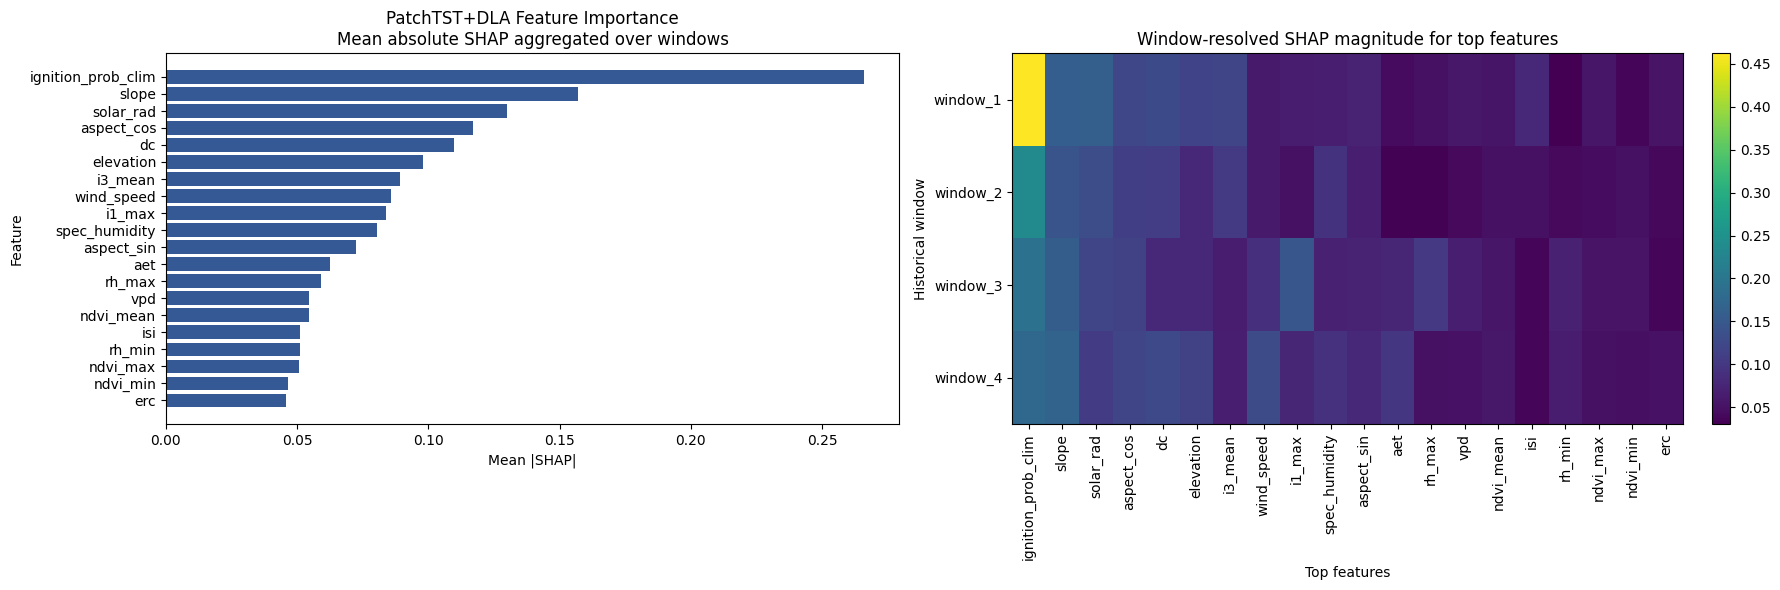

,feature,mean_abs_shap
0,ignition_prob_clim,0.266111
1,slope,0.156946
2,solar_rad,0.129981
3,aspect_cos,0.117095
4,dc,0.109951
5,elevation,0.097936
6,i3_mean,0.089260
7,wind_speed,0.085628
8,i1_max,0.084012
9,spec_humidity,0.080447


Saved SHAP feature importance to: /kaggle/working/ensemble_patchtst_tree/patchtst_shap_feature_importance.csv
Short interpretation:
- Larger mean |SHAP| indicates a stronger average contribution to the PatchTST+DLA logit.
- The bar chart aggregates attribution across the four historical windows.
- The heatmap shows how the same top features contribute across individual windows.
- These values explain the neural branch only, not the tree models or the stacked meta-classifier.


In [10]:
# -------------------------
# SHAP feature importance for PatchTST+DLA
# -------------------------
import shap
from IPython.display import display

SHAP_BACKGROUND_SIZE = 128
SHAP_EXPLAIN_SIZE = 256
SHAP_NSAMPLES = 128
SHAP_TOP_K = 20


def _sample_rows(x: np.ndarray, n_rows: int, seed: int) -> np.ndarray:
    """Sample rows without replacement for SHAP background/explanation sets."""
    if x.shape[0] <= int(n_rows):
        return x
    rng = np.random.default_rng(int(seed))
    idx = rng.choice(x.shape[0], size=int(n_rows), replace=False)
    return x[idx]


class PatchTSTLogitWrapper(torch.nn.Module):
    """Expose the trained PatchTST+DLA classifier as a single-logit model for SHAP."""
    def __init__(self, model: torch.nn.Module):
        super().__init__()
        self.model = model

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x).unsqueeze(-1)


def _coerce_shap_values(values: object) -> np.ndarray:
    """Convert SHAP output to a dense array with shape [N, T, F]."""
    if isinstance(values, list):
        if len(values) != 1:
            raise ValueError(f'Expected one SHAP output array, got {len(values)}')
        values = values[0]

    arr = np.asarray(values)
    if arr.ndim == 4:
        if arr.shape[-1] == 1:
            arr = arr[..., 0]
        elif arr.shape[1] == 1:
            arr = arr[:, 0, :, :]
    if arr.ndim != 3:
        raise ValueError(f'Expected SHAP array with 3 dims [N,T,F], got {arr.shape}')
    return arr.astype(np.float32)


patchtst_base_model = trained_model.module if hasattr(trained_model, 'module') else trained_model
patchtst_base_model.eval()
shap_device = device if isinstance(device, torch.device) else torch.device(device)

background_np = _sample_rows(train_arr.x, SHAP_BACKGROUND_SIZE, SEED)
explain_np = _sample_rows(val_arr.x, SHAP_EXPLAIN_SIZE, SEED + 1)

background_t = torch.tensor(background_np, dtype=torch.float32, device=shap_device)
explain_t = torch.tensor(explain_np, dtype=torch.float32, device=shap_device)

shap_model = PatchTSTLogitWrapper(patchtst_base_model).to(shap_device)
explainer = shap.GradientExplainer(shap_model, background_t)
shap_values = _coerce_shap_values(
    explainer.shap_values(explain_t, nsamples=SHAP_NSAMPLES)
)

abs_shap = np.abs(shap_values)
feature_importance = abs_shap.mean(axis=(0, 1))
window_feature_importance = abs_shap.mean(axis=0)  # [T, F]

patchtst_shap_df = (
    pd.DataFrame({
        'feature': train_arr.feature_cols,
        'mean_abs_shap': feature_importance,
    })
    .sort_values('mean_abs_shap', ascending=False)
    .reset_index(drop=True)
)

top_shap_df = patchtst_shap_df.head(SHAP_TOP_K).copy()
top_feature_names = top_shap_df['feature'].tolist()
top_feature_idx = [train_arr.feature_cols.index(name) for name in top_feature_names]
heatmap_values = window_feature_importance[:, top_feature_idx]

save_fp = ARTIFACT_DIR / 'patchtst_shap_feature_importance.csv'
patchtst_shap_df.to_csv(save_fp, index=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(
    top_shap_df['feature'][::-1],
    top_shap_df['mean_abs_shap'][::-1],
    color='#345995'
)
axes[0].set_title('PatchTST+DLA Feature Importance\nMean absolute SHAP aggregated over windows')
axes[0].set_xlabel('Mean |SHAP|')
axes[0].set_ylabel('Feature')

im = axes[1].imshow(heatmap_values, aspect='auto', cmap='viridis')
axes[1].set_title('Window-resolved SHAP magnitude for top features')
axes[1].set_xlabel('Top features')
axes[1].set_ylabel('Historical window')
axes[1].set_xticks(np.arange(len(top_feature_names)))
axes[1].set_xticklabels(top_feature_names, rotation=90)
axes[1].set_yticks(np.arange(heatmap_values.shape[0]))
axes[1].set_yticklabels([f'window_{i+1}' for i in range(heatmap_values.shape[0])])
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

display(top_shap_df.round(6))

print('Saved SHAP feature importance to:', save_fp)
print('Short interpretation:')
print('- Larger mean |SHAP| indicates a stronger average contribution to the PatchTST+DLA logit.')
print('- The bar chart aggregates attribution across the four historical windows.')
print('- The heatmap shows how the same top features contribute across individual windows.')
print('- These values explain the neural branch only, not the tree models or the stacked meta-classifier.')


## Tree Baselines and Stacked Meta-Classifier

The remaining stages convert the same four-window tensor into flat statistical descriptors, train the tree baselines, and then combine all base-model probabilities through a meta-MLP. This provides a direct comparison between the neural branch, the tree branch, and the final stacked ensemble.


In [11]:
# -------------------------
# Flat feature engineering for tree models
# -------------------------
def make_flat_features(X, feature_cols):
    """[N,T,F] -> [N, T*F + 4*F] (raw + mean + std + last + trend)."""
    N, T, F = X.shape
    flat = X.reshape(N, T * F)
    mu = X.mean(axis=1)
    sd = X.std(axis=1)
    last = X[:, -1, :]
    trend = X[:, -1, :] - X[:, 0, :]
    out = np.concatenate([flat, mu, sd, last, trend], axis=1).astype(np.float32)

    raw_names = [f'w{t+1}_{f}' for t in range(T) for f in feature_cols]
    extra_names = (
        [f'mean_{f}' for f in feature_cols] +
        [f'std_{f}' for f in feature_cols] +
        [f'last_{f}' for f in feature_cols] +
        [f'trend_{f}' for f in feature_cols]
    )
    return out, raw_names + extra_names

X_train_flat, flat_names = make_flat_features(train_arr.x, train_arr.feature_cols)
X_val_flat, _ = make_flat_features(val_arr.x, train_arr.feature_cols)
X_test_flat, _ = make_flat_features(test_arr.x, train_arr.feature_cols)

# Standard scaling for stable tree/MLP comparisons
flat_scaler = StandardScaler()
X_train_flat = flat_scaler.fit_transform(X_train_flat).astype(np.float32)
X_val_flat = flat_scaler.transform(X_val_flat).astype(np.float32)
X_test_flat = flat_scaler.transform(X_test_flat).astype(np.float32)

print('Flat shape train/val/test:', X_train_flat.shape, X_val_flat.shape, X_test_flat.shape)

Flat shape train/val/test: (47530, 344) (10290, 344) (1890, 344)


In [12]:
# -------------------------
# Metric helpers
# -------------------------
def iou_score(tp, fp, fn):
    return tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0


def metrics_at_threshold(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return {
        'threshold': float(thr),
        'pr_auc': float(average_precision_score(y_true, y_prob)),
        'precision': float(prec),
        'recall': float(rec),
        'f1': float(f1),
        'iou': float(iou_score(tp, fp, fn)),
        'specificity': float(spec),
        'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn),
    }


def tune_threshold(y_true, y_prob, grid=np.linspace(0.05, 0.95, 19)):
    best_thr, best_f1 = 0.5, -1.0
    for thr in grid:
        f1 = f1_score(y_true, (y_prob >= thr).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1 = float(f1)
            best_thr = float(thr)
    return best_thr


In [13]:
# -------------------------
# Train tree baselines safely
# -------------------------
base_val_probs = {"patchtst_dla": patch_val_prob}
base_test_probs = {"patchtst_dla": patch_test_prob}

y_train_tree = np.asarray(train_arr.y).astype(np.int32).ravel()
y_val_tree = np.asarray(y_val).astype(np.int32).ravel()
y_test_tree = np.asarray(y_test).astype(np.int32).ravel()

scale_pos = float((y_train_tree == 0).sum()) / max(float((y_train_tree == 1).sum()), 1.0)

print("Tree train shapes:", X_train_flat.shape, y_train_tree.shape)
print("Tree val shapes:", X_val_flat.shape, y_val_tree.shape)
print("scale_pos:", scale_pos)


# -------------------------
# XGBoost
# -------------------------
if TREE_IMPORTS["xgboost"]:
    try:
        xgb_model = xgb.XGBClassifier(
            n_estimators=1000,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=5,
            scale_pos_weight=scale_pos,
            tree_method="hist",
            eval_metric="aucpr",
            early_stopping_rounds=30,
            random_state=SEED,
            verbosity=0,
        )

        xgb_model.fit(
            X_train_flat,
            y_train_tree,
            eval_set=[(X_val_flat, y_val_tree)],
            verbose=False,
        )

        base_val_probs["xgboost"] = xgb_model.predict_proba(X_val_flat)[:, 1].astype(np.float32)
        base_test_probs["xgboost"] = xgb_model.predict_proba(X_test_flat)[:, 1].astype(np.float32)

        print("XGBoost trained.")

    except Exception as e:
        print("XGBoost failed:", repr(e))


# -------------------------
# CatBoost
# -------------------------
if TREE_IMPORTS["catboost"]:
    try:
        cat_model = cb.CatBoostClassifier(
            iterations=1000,
            depth=6,
            learning_rate=0.05,
            loss_function="Logloss",
            eval_metric="PRAUC",
            early_stopping_rounds=30,
            random_seed=SEED,
            verbose=False,
            task_type="CPU"   # safest for Kaggle compatibility
        )

        cat_model.fit(
            X_train_flat,
            y_train_tree,
            eval_set=(X_val_flat, y_val_tree),
            use_best_model=True,
        )

        base_val_probs["catboost"] = cat_model.predict_proba(X_val_flat)[:, 1].astype(np.float32)
        base_test_probs["catboost"] = cat_model.predict_proba(X_test_flat)[:, 1].astype(np.float32)

        print("CatBoost trained.")

    except Exception as e:
        print("CatBoost failed:", repr(e))


# -------------------------
# LightGBM
# -------------------------
if TREE_IMPORTS["lightgbm"]:
    try:
        lgb_model = lgb.LGBMClassifier(
            n_estimators=1000,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_samples=20,
            scale_pos_weight=scale_pos,
            objective="binary",
            random_state=SEED,
            verbose=-1,
            device_type="cpu"   # safest
        )

        lgb_model.fit(
            X_train_flat,
            y_train_tree,
            eval_set=[(X_val_flat, y_val_tree)],
            eval_metric="average_precision",
            callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)],
        )

        base_val_probs["lightgbm"] = lgb_model.predict_proba(X_val_flat)[:, 1].astype(np.float32)
        base_test_probs["lightgbm"] = lgb_model.predict_proba(X_test_flat)[:, 1].astype(np.float32)

        print("LightGBM trained.")

    except Exception as e:
        print("LightGBM failed:", repr(e))


print("Base models used:", list(base_val_probs.keys()))

Tree train shapes: (47530, 344) (47530,)
Tree val shapes: (10290, 344) (10290,)
scale_pos: 1.0
XGBoost trained.
CatBoost trained.
LightGBM trained.
Base models used: ['patchtst_dla', 'xgboost', 'catboost', 'lightgbm']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [14]:
# -------------------------
# Build stacking matrices
# -------------------------
model_names = sorted(base_val_probs.keys())

S_val = np.column_stack([base_val_probs[m] for m in model_names]).astype(np.float32)
S_test = np.column_stack([base_test_probs[m] for m in model_names]).astype(np.float32)

print('Stack val matrix:', S_val.shape)
print('Stack test matrix:', S_test.shape)
print('Meta features:', model_names)


Stack val matrix: (10290, 4)
Stack test matrix: (1890, 4)
Meta features: ['catboost', 'lightgbm', 'patchtst_dla', 'xgboost']


In [15]:
# -------------------------
# Meta-classifier: MLP on base probabilities
# -------------------------
meta_scaler = StandardScaler()
S_val_sc = meta_scaler.fit_transform(S_val)
S_test_sc = meta_scaler.transform(S_test)

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import average_precision_score
import numpy as np

class MetaMLP(nn.Module):
    def __init__(self, in_dim, hidden=(32, 16), activation="gelu", dropout=0.1):
        super().__init__()

        acts = {
            "relu": nn.ReLU(),
            "gelu": nn.GELU(),
            "silu": nn.SiLU(),
            "leaky_relu": nn.LeakyReLU(0.1),
        }

        act = acts[activation]

        layers = []
        prev = in_dim

        for h in hidden:
            layers += [
                nn.Linear(prev, h),
                act,
                nn.Dropout(dropout)
            ]
            prev = h

        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)

In [17]:
def train_meta_mlp(
    S_val_sc, y_val,
    activation="gelu",
    hidden=(32, 16),
    lr=1e-3,
    weight_decay=1e-4,
    epochs=500,
    patience=40,
    device=None
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    X = torch.tensor(S_val_sc, dtype=torch.float32).to(device)
    y = torch.tensor(y_val, dtype=torch.float32).to(device)

    model = MetaMLP(
        in_dim=S_val_sc.shape[1],
        hidden=hidden,
        activation=activation,
        dropout=0.1
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()

    best_loss = float("inf")
    best_state = None
    wait = 0

    for epoch in range(epochs):
        model.train()

        logits = model(X)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if loss.item() < best_loss:
            best_loss = loss.item()
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    model.load_state_dict(best_state)
    return model

In [18]:
activations = ["relu", "gelu", "silu", "leaky_relu"]

results = {}

device = "cuda" if torch.cuda.is_available() else "cpu"

for act in activations:
    print(f"\n==== Training Meta MLP with {act} ====")

    model = train_meta_mlp(
        S_val_sc,
        y_val,
        activation=act,
        hidden=(32, 16),
        lr=1e-3,
        weight_decay=1e-4,
        device=device
    )

    model.eval()

    with torch.no_grad():
        val_prob = torch.sigmoid(
            model(torch.tensor(S_val_sc, dtype=torch.float32).to(device))
        ).cpu().numpy().astype(np.float32)

        test_prob = torch.sigmoid(
            model(torch.tensor(S_test_sc, dtype=torch.float32).to(device))
        ).cpu().numpy().astype(np.float32)

    thr = tune_threshold(y_val, val_prob)

    val_metrics = metrics_at_threshold(y_val, val_prob, thr)
    test_metrics = metrics_at_threshold(y_test, test_prob, thr)

    results[act] = {
        "threshold": thr,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics
    }

    print(f"{act} → thr={thr:.4f}, val_PR={val_metrics['pr_auc']:.4f}, test_PR={test_metrics['pr_auc']:.4f}")


# -------------------------
# Best activation
# -------------------------
best_act = max(results, key=lambda k: results[k]["val_metrics"]["pr_auc"])

print("\n===== FINAL BEST =====")
print("Best activation:", best_act)
print("Details:", results[best_act])


==== Training Meta MLP with relu ====
relu → thr=0.3500, val_PR=0.8532, test_PR=0.8765

==== Training Meta MLP with gelu ====
gelu → thr=0.3000, val_PR=0.8515, test_PR=0.8777

==== Training Meta MLP with silu ====
silu → thr=0.3000, val_PR=0.8503, test_PR=0.8774

==== Training Meta MLP with leaky_relu ====
leaky_relu → thr=0.3500, val_PR=0.8523, test_PR=0.8756

===== FINAL BEST =====
Best activation: relu
Details: {'threshold': 0.35, 'val_metrics': {'threshold': 0.35, 'pr_auc': 0.853160733080165, 'precision': 0.7026811362910947, 'recall': 0.85578231292517, 'f1': 0.7717115064411533, 'iou': 0.6282819634703196, 'specificity': 0.6379008746355685, 'tp': 4403, 'fp': 1863, 'fn': 742, 'tn': 3282}, 'test_metrics': {'threshold': 0.35, 'pr_auc': 0.8765444359334117, 'precision': 0.74, 'recall': 0.8222222222222222, 'f1': 0.7789473684210526, 'iou': 0.6379310344827587, 'specificity': 0.7111111111111111, 'tp': 777, 'fp': 273, 'fn': 168, 'tn': 672}}
